In [1]:
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = f"{analysis_directory.name}/counts.zarr"
repack_store(f"{dataset}/data.zarr", repacked_counts, nthreads=2)
ds = scarf.mount_datastore(
    repacked_counts,
    at=f"{analysis_directory.name}/analysis.zarr",
    nthreads=4,
    default_assay="RNA",
)

preparation = ds.pipeline.run(
    filtering=False,
    hvg_count=2000,
    pca_dims=15,
    neighbors_k=11,
    umap=False,
    leiden=False,
    cell_cycle=False,
    paris=False,
    doublets=False,
    markers=False,
)
graph = preparation["connectivity_map"]
all_features = preparation["feature_universe"]

annotations = np.asarray(ds.cells.fetch("clusters", key="I"))
source = annotations == "Ductal"
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])
if not source.any() or not sink.any() or np.any(source & sink):
    raise ValueError("Source and sink annotations must be non-empty and disjoint")
source_sink_vector = np.zeros(len(annotations), dtype=float)
source_sink_vector[source] = 1.0 / int(source.sum())
source_sink_vector[sink] = -1.0 / int(sink.sum())
pseudotime_ref = ds.run_pseudotime_scoring(graph, ss_vec=source_sink_vector)

Downloading bucket files: 43423201 / 43423201 complete

Downloading bytes: 43423201 / 43423201 complete

Repacking RNA/artifacts/normalized//data: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

...

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

In [2]:
modules_ref = ds.run_pseudotime_aggregation(
    pseudotime_ref,
    features=all_features,
    n_clusters=15,
    window_size=200,
    chunk_size=100,
)
modules = ds.load_pseudotime_aggregation(modules_ref)
{
    "artifact": modules.ref,
    "pseudotime": modules.pseudotime,
    "feature selection": modules.feature_selection,
    "assigned features": len(modules.feature_indices),
}

Binning over cell-ordering: 2 / 2 complete

Fitting feature KNN: 1 / 1 complete

Identifying feature neighbors: 1 / 1 complete

Sorting clusters: 1 / 1 complete

{'artifact': ArtifactRef(assay='RNA', kind='pseudotime_aggregation', artifact_id='e20ad08cc502...'),
 'pseudotime': ArtifactRef(assay='RNA', kind='pseudotime', artifact_id='fe813e1ca284...'),
 'feature selection': ArtifactRef(assay='RNA', kind='feature_selection', artifact_id='ae1a5220e57b...'),
 'assigned features': 12455}

In [3]:
feature_names = np.asarray(ds.RNA.feats.fetch_all("names"))[modules.feature_indices]
module_frame = pd.DataFrame(
    {
        "feature_name": feature_names,
        "module": modules.feature_clusters,
    }
)
module_frame["module"].value_counts().sort_index()

module
1     1045
2      533
3     1318
4     1156
5     1414
6      121
7     1145
8      221
9     1264
10     273
11     787
12     642
13     964
14    1071
15     501
Name: count, dtype: int64

In [4]:
examples = (
    module_frame.groupby("module", sort=True)["feature_name"]
    .first()
    .rename("example gene")
)
examples

module
1       Vcpip1
2        Ncoa2
3        Tcf24
4     Tgfbrap1
5         Phf3
6      Fam163a
7        Cops5
8        Smap1
9       Sema4c
10        Tns1
11      Mrpl15
12      Neurl3
13       Tram2
14     Ppp1r42
15      Sbspon
Name: example gene, dtype: str

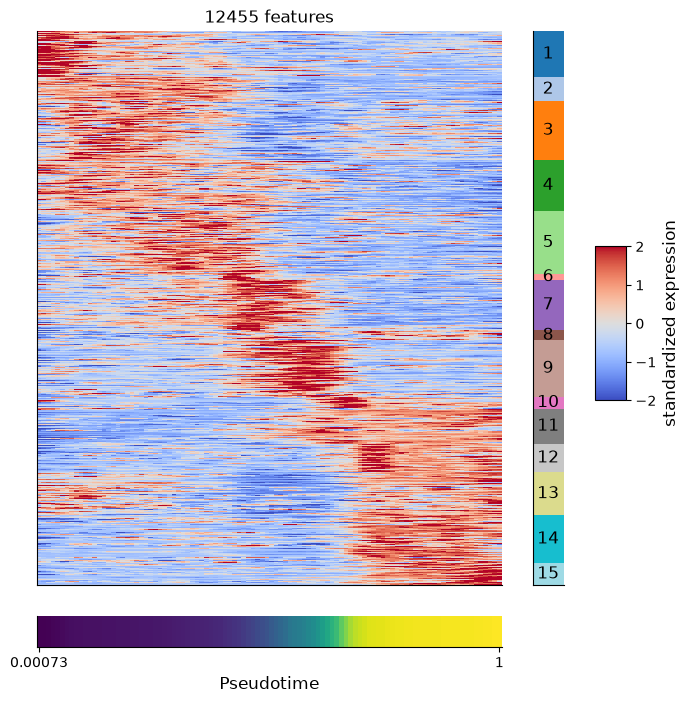

In [5]:
ds.plots.pseudotime_heatmap(
    aggregation=modules_ref,
    figsize=(8, 8),
)

In [6]:
ds.add_grouped_assay(
    modules_ref,
    assay_label="TrajectoryModules",
)
ds.TrajectoryModules

Writing grouped assay: 1 / 1 complete

Computing TrajectoryModules initialization statistics: 1 / 1 complete

Assay TrajectoryModules with 15 features